In [1]:
import tensorflow as tf

# 사용 가능한 GPU 목록을 출력합니다.
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"✅ GPU가 켜져 있습니다! 인식된 GPU 개수: {len(gpus)}개")
    for gpu in gpus:
        print(gpu)
else:
    print("❌ GPU를 찾을 수 없습니다. (현재 CPU로만 동작 중)")

❌ GPU를 찾을 수 없습니다. (현재 CPU로만 동작 중)


In [1]:
!pip install opencv-python matplotlib

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   -- ------------------------------------- 2.9/44.0 MB 13.5 MB/s eta 0:00:04
   ---- ----------------------------------- 4.5/44.0 MB 10.5 MB/s eta 0:00:04
   ----- ---------------------------------- 5.8/44.0 MB 8.5 MB/s eta 0:00:05
   ----- ---------------------------------- 6.3/44.0 MB 7.1 MB/s eta 0:00:06
   ------ --------------------------------- 7.1/44.0 MB 6.3 MB/s eta 0:00:06
   ------- -------------------------------- 8.4/44.0 MB 6.1 MB/s eta 0:00:06
   -------- ------------------------------- 9.2/44.0 MB 5.4 MB/s eta 0:00:07
   --------- ------------------------------ 10.2/44.0 MB 5.2 MB/s eta 0:00:07
   ---------- ----------------------------- 11.8/44.0 MB 5.0 MB/s eta 0:00:07
   ----------- ---------------------------- 12.3/44.0 MB 4.7 MB/s eta 0:00:07
   ------------ --------------------------- 13.9/44.0 MB 4.6 MB/s eta 0:00:07
   ------------- -------------------------- 15.2/44.0 MB 4.6 MB/s eta 0:00:07

In [2]:
import json
from pathlib import Path

def find_anomalous_json_files(folder_path):
    """
    주어진 폴더 경로에서 json 파일을 읽고, 
    'failure_case_count'가 1이 아닌 파일들의 목록을 반환합니다.
    """
    target_files = []
    
    # 폴더 경로를 Path 객체로 변환
    path = Path(folder_path)
    
    # 폴더 내의 모든 .json 파일 탐색
    for file_path in path.glob('*.json'):
        try:
            # utf-8 인코딩으로 파일 열기
            with open(file_path, 'r', encoding='utf-8') as file:
                data = json.load(file)
                
                # failure_case_count 값 확인 (키가 없는 경우 None을 반환하므로 1과 다름)
                failure_count = data.get("failure_case_count")
                
                if failure_count != 1:
                    target_files.append(str(file_path))
                    
        except json.JSONDecodeError:
            print(f"⚠️ JSON 파싱 에러 (파일이 손상되었거나 형식이 맞지 않습니다): {file_path.name}")
        except Exception as e:
            print(f"⚠️ 파일을 읽는 중 오류 발생 ({file_path.name}): {e}")
            
    return target_files

# --- 사용 예시 ---
if __name__ == "__main__":
    # 탐색할 폴더 경로를 여기에 입력하세요
    folder_directory = 'C:/Users/User/Downloads/full_images/CT/main/augmentation_json'
    
    result = find_anomalous_json_files(folder_directory)
    
    print(f"총 {len(result)}개의 파일을 찾았습니다.")
    for res_file in result:
        print(f"- {res_file}")

총 0개의 파일을 찾았습니다.


C:\Users\User\anaconda3\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_4']
Received: inputs=Tensor(shape=(1, 320, 320, 3))
  warnings.warn(msg)


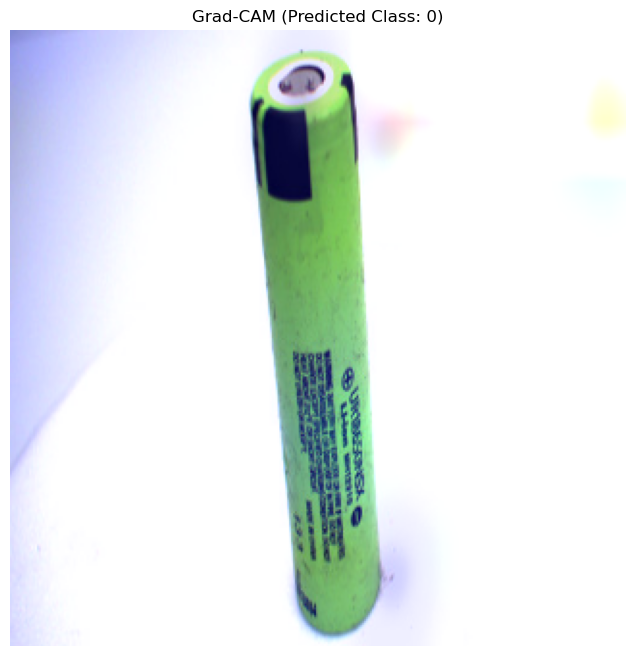

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import matplotlib.cm as cm
import matplotlib

# ==========================================
# 1. 설정값 지정 
# ==========================================
model_path = 'C:/Users/User/Downloads/saved_models/inspection_model_test_1.keras'
img_path = 'C:/Users/User/Downloads/full_images/05_RGB_cell_cylindrical_0731_182.jpg'
#11_RGB_cell_cylindrical_0056_073
img_size = (320,320) 
# ==========================================
# 2. 모델 및 이미지 불러오기
# ==========================================
model = tf.keras.models.load_model(model_path)

img = tf.keras.utils.load_img(img_path, target_size=img_size)
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.mobilenet_v3.preprocess_input(img_array)

# ==========================================
# 3. 맞춤형 Grad-CAM 히트맵 생성 함수 (입력 경고 수정)
# ==========================================
def make_gradcam_heatmap_custom(img_array, model):
    base_model = model.layers[0]       
    classifier_layer = model.layers[1] 
    
    # 소문자 conv_1 반영
    last_conv_layer = base_model.get_layer('conv_1')
    
    # 수정: inputs에 있던 대괄호([]) 제거하여 구조 맞춤 (Warning 1 해결)
    base_grad_model = tf.keras.models.Model(
        inputs=base_model.inputs, 
        outputs=[last_conv_layer.output, base_model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, base_outputs = base_grad_model(img_array)
        tape.watch(conv_outputs) 
        
        preds = classifier_layer(base_outputs)
        top_pred_index = tf.argmax(preds[0])
        class_channel = preds[:, top_pred_index] 

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), top_pred_index.numpy()

# ==========================================
# 4. 시각화 및 실행 (에러 및 Matplotlib 경고, 색상 수정)
# ==========================================
def display_gradcam(img_path, heatmap, pred_class, alpha=0.4):
    # OpenCV는 BGR로 이미지를 읽으므로 RGB로 색상 변환 (색상 오류 방지)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    
    # 히트맵 생성 및 컬러맵 적용
    heatmap = np.uint8(255 * heatmap)
    
    # 수정: 최신 Matplotlib 버전에 맞춘 컬러맵 호출 (Warning 2 해결)
    jet = matplotlib.colormaps["jet"]
    jet_colors = jet(np.arange(256))[:, :3] # 0~1 사이의 RGB 값
    jet_heatmap = jet_colors[heatmap] * 255 # 0~255 스케일로 변환
    
    # 히트맵을 원본 이미지 크기에 맞게 확대 (NumPy 배열 상태 유지)
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))
    
    # 수정: 합성 연산 (배열끼리 더하므로 TypeError 해결)
    superimposed_img = jet_heatmap * alpha + img
    
    # 합성된 결과의 값을 0~255 사이로 맞춘 후 이미지 객체로 최종 변환
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)
    
    # 화면에 출력
    plt.figure(figsize=(8, 8))
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title(f"Grad-CAM (Predicted Class: {pred_class})") 
    plt.show()

# 실행 코드는 동일하게 유지
heatmap, pred_class = make_gradcam_heatmap_custom(img_array, model)
display_gradcam(img_path, heatmap, pred_class)

In [3]:
import os
import shutil

def separate_images(json_dir, image_dir, output_dir):
    # 1. 저장할 폴더 생성
    pass_dir = os.path.join(output_dir, 'pass')
    fail_dir = os.path.join(output_dir, 'fail')
    os.makedirs(pass_dir, exist_ok=True)
    os.makedirs(fail_dir, exist_ok=True)

    # 2. fail 대상인 이미지의 원본 이름만 담아둘 Set(집합) 생성
    fail_base_names = set()

    for json_file in os.listdir(json_dir):
        # 파일명에 'augmentation'이 들어간 경우만 처리
        if 'augmentation' in json_file:
            # 예: RGB_cell_123.augmentation.json -> RGB_cell_123 추출
            base_name = json_file.split('.augmentation')[0].split('_augmentation')[0]
            fail_base_names.add(base_name)

    pass_count = 0
    fail_count = 0

    # 3. '이미지 폴더'의 전체 19000장 이미지를 기준으로 분류 시작
    for img_file in os.listdir(image_dir):
        # 폴더 등 파일이 아닌 것은 건너뛰기
        if not os.path.isfile(os.path.join(image_dir, img_file)):
            continue

        # 이미지 파일의 순수 이름 추출 (확장자 제거)
        # 예: RGB_cell_123.jpg -> RGB_cell_123
        base_img_name, _ = os.path.splitext(img_file)
        
        src_path = os.path.join(image_dir, img_file)

        # 4. 추출한 이미지 이름이 fail 리스트에 있으면 fail, 없으면 pass로 복사
        if base_img_name in fail_base_names:
            dst_path = os.path.join(fail_dir, img_file)
            fail_count += 1
        else:
            dst_path = os.path.join(pass_dir, img_file)
            pass_count += 1

        # 원본을 유지하면서 복사 (이동을 원하시면 shutil.move(src_path, dst_path) 사용)
        shutil.copy2(src_path, dst_path)

    # 결과 출력
    print(f"✅ 분류 작업이 완료되었습니다!")
    print(f"   - 정상 (Pass) 이미지: {pass_count}장")
    print(f"   - 불량 (Fail) 이미지: {fail_count}장")
    print(f"   - 총 처리된 이미지: {pass_count + fail_count}장")

# ==========================================
# 실행 부분
# ==========================================
if __name__ == '__main__':
    # 본인 환경에 맞게 경로를 수정해주세요.
    # JSON 파일들이 모여있는 폴더 경로
    JSON_FOLDER = 'C:/Users/User/Downloads/full_images/RGB/main/augmentation_json'
    
    # 이미지 파일들이 모여있는 폴더 경로
    IMAGE_FOLDER = "C:/Users/User/Downloads/full_images/RGB/main/images"
    
    # 분류된 이미지를 저장할 최상위 폴더 경로 (이 아래에 pass/fail 폴더가 생성됨)
    OUTPUT_FOLDER = 'C:/Users/User/Downloads/full_images/RGB/main'

    separate_images(JSON_FOLDER, IMAGE_FOLDER, OUTPUT_FOLDER)

✅ 분류 작업이 완료되었습니다!
   - 정상 (Pass) 이미지: 17100장
   - 불량 (Fail) 이미지: 1900장
   - 총 처리된 이미지: 19000장


In [ ]:
if __name__ == '__main__':
    # JSON 파일들이 모여있는 폴더 경로
    JSON_FOLDER = 'C:/Users/User/Downloads/full_images/RGB/main/augmentation_json'
    
    # 이미지 파일들이 모여있는 폴더 경로
    IMAGE_FOLDER = "C:/Users/User/Downloads/full_images/RGB/main/images"
    
    # 분류된 이미지를 저장할 최상위 폴더 경로 (이 아래에 pass/fail 폴더가 생성됨)
    OUTPUT_FOLDER = 'C:/Users/User/Downloads/full_images/RGB/main'

    separate_images(JSON_FOLDER, IMAGE_FOLDER, OUTPUT_FOLDER)